<Axes: xlabel='correctAlternative'>

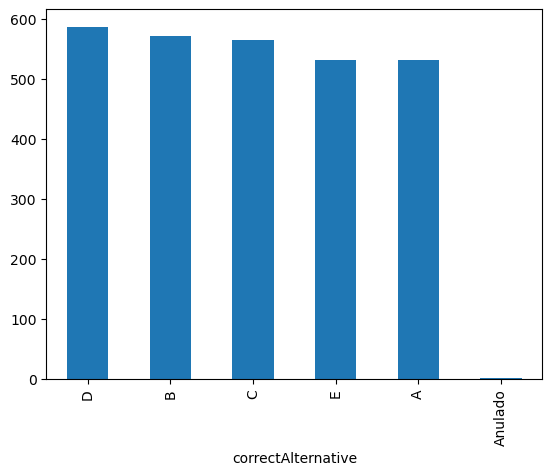

In [51]:
df['correctAlternative'].value_counts().plot.bar()

<Axes: xlabel='discipline'>

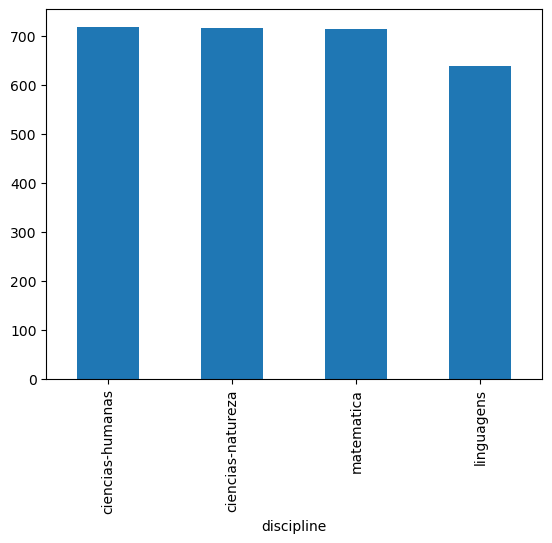

In [7]:
df['discipline'].value_counts().plot.bar()

In [4]:
df.groupby(["year","discipline"]).size().unstack(fill_value=0)

discipline,ciencias-humanas,ciencias-natureza,linguagens,matematica
year,,,,
2009,45,45,39,45
2010,45,45,40,45
2011,45,45,40,45
2012,45,45,40,45
2013,45,45,40,45
2014,45,45,40,45
2015,45,45,40,44
2016,45,45,40,45
2017,45,45,40,45


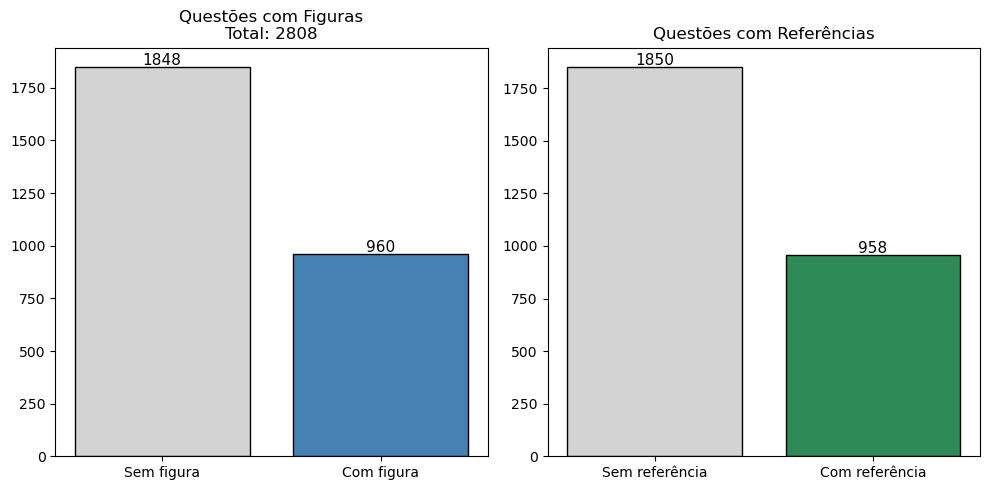

📊 Resumo:
  Total de questões: 2808
  Com figuras: 960 (34.2%)
  Com referências: 958 (34.1%)


In [33]:
# Criar colunas de análise
df['tem_figura'] = df['context'].str.contains(r'!\[.*?\]\(.*?\)', regex=True, na=False)
df['tem_referencia'] = df['context'].str.contains(r'[A-ZÀ-ÿ]+, [A-ZÀ-ÿ]\.', regex=True, na=False)

# Contagens
com_figura = df['tem_figura'].sum()
sem_figura = len(df) - com_figura
com_referencia = df['tem_referencia'].sum()

# Gráfico
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Figuras
axes[0].bar(['Sem figura', 'Com figura'], [sem_figura, com_figura], 
            color=['lightgray', 'steelblue'], edgecolor='black')
axes[0].set_title(f'Questões com Figuras\nTotal: {len(df)}')
for i, v in enumerate([sem_figura, com_figura]):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=11)

# Referências
axes[1].bar(['Sem referência', 'Com referência'], 
            [len(df) - com_referencia, com_referencia], 
            color=['lightgray', 'seagreen'], edgecolor='black')
axes[1].set_title(f'Questões com Referências')
for i, v in enumerate([len(df) - com_referencia, com_referencia]):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print(f"📊 Resumo:")
print(f"  Total de questões: {len(df)}")
print(f"  Com figuras: {com_figura} ({100*com_figura/len(df):.1f}%)")
print(f"  Com referências: {com_referencia} ({100*com_referencia/len(df):.1f}%)")

In [2]:
import json

# Carregar 2009-2023
with open('questoes_enem_todas.json', 'r', encoding='utf-8') as f:
    questoes_2009_2023 = json.load(f)

# Carregar 2024
with open('2024.json', 'r', encoding='utf-8') as f:
    questoes_2024 = json.load(f)

# Juntar
todas = questoes_2009_2023 + questoes_2024

# Salvar
with open('enem_completo.json', 'w', encoding='utf-8') as f:
    json.dump(todas, f, ensure_ascii=False, indent=2)

print(f"2009-2023: {len(questoes_2009_2023)} questões")
print(f"2024: {len(questoes_2024)} questões")
print(f"✅ Total: {len(todas)} questões em enem_completo.json")

2009-2023: 2757 questões
2024: 180 questões
✅ Total: 2937 questões em enem_completo.json


In [6]:
df.columns

Index(['title', 'index', 'year', 'language', 'discipline', 'context', 'files',
       'correctAlternative', 'alternativesIntroduction', 'alternatives'],
      dtype='object')

In [55]:
import jsonresposta_correta

# Carregar 2009-2023
with open('questoes_enem_todas.json', 'r', encoding='utf-8') as f:
    questoes_2009_2023 = json.load(f)

# Juntar context + alternativesIntroduction nas anteriores|
for q in questoes_2009_2023:
    intro = q.get('alternativesIntroduction')
    ctx = q.get('context') or ''
    
    if intro:
        q['context'] = ctx + '\n' + intro
    q['alternativesIntroduction'] = None

# Carregar 2024
with open('2024.json', 'r', encoding='utf-8') as f:
    questoes_2024 = json.load(f)

# Juntar e salvar
todas = questoes_2009_2023 + questoes_2024

with open('enem_completo.json', 'w', encoding='utf-8') as f:
    json.dump(todas, f, ensure_ascii=False, indent=2)

print(f"✅ {len(todas)} questões salvas em enem_completo.json")

✅ 2937 questões salvas em enem_completo.json


==========================================================================================================

In [42]:
import pandas as pd

df = pd.read_json('enem_completo.json')

def atribuir_disciplina(index, year):

    if year <= 2016:
        if 1 <= index <= 45:
            return "ciencias-humanas"
        elif 46 <= index <= 90:
            return "ciencias-natureza"
        elif 91 <= index <= 135:
            return "linguagens"
        elif 136 <= index <= 180:
            return "matematica"

    else:
        if 1 <= index <= 45:
            return "linguagens"
        elif 46 <= index <= 90:
            return "ciencias-humanas"
        elif 91 <= index <= 135:
            return "ciencias-natureza"
        elif 136 <= index <= 180:
            return "matematica"

    return None


df["discipline"] = df.apply(
    lambda row: atribuir_disciplina(
        row["index"],
        row["year"]
    ),
    axis=1
)

print("Questões sem disciplina:",
      df["discipline"].isna().sum())

df.to_json(
    "enem_completo.json",
    orient="records",
    force_ascii=False,
    indent=2
)

print(f"✅ Disciplinas atribuídas. Total: {len(df)} questões")

Questões sem disciplina: 0
✅ Disciplinas atribuídas. Total: 2937 questões


A partir daqui os dados estão limpos e organizados. A partir daqui serão aplicados os modelos de ML necessários.

Questões → Embeddings → Clusters → Rotular 1 questão por cluster → Propagar rótulos

In [43]:
def eh_lingua_estrangeira(index, year):

    if year <= 2016:
        # Linguagens está em 91–135
        return 131 <= index <= 135

    else:
        # Linguagens está em 1–45
        return 41 <= index <= 45

mask = (
    ((df["year"] <= 2016) &
     (df["index"].between(91,95)))
    |
    ((df["year"] >= 2017) &
     (df["index"].between(1,5)))
)

df = df[~mask].copy()

In [24]:
import pandas as pd

mr = pd.read_csv('matriz_de_referencia.csv')

In [44]:
df[df['language'] == 'ingles']


,title,index,year,language,discipline,context,files,correctAlternative,alternativesIntroduction,alternatives


In [45]:
mapeamento = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
df['correctIndex'] = df['correctAlternative'].map(mapeamento)

def extrair_correta(alternativas):
    for alt in alternativas:
        if alt and alt.get('isCorrect'):
            return alt['text']
    return None

df['resposta_correta'] = df['alternatives'].apply(extrair_correta)

# Substituir links de imagens por [FIGURA]
df['context'] = df['context'].str.replace(
    r'!\[.*?\]\(https?://[^\s)]+\)', 
    '[FIGURA]', 
    regex=True
)


# Remover quebras de linha desnecessárias
df["context"] = df["context"].str.replace("\n", " ").str.replace("  ", " ")

    
# Lista de valores que você quer remover
valores_remover = ["Anulado", "Nulo", "Sem resposta", ""]

# Remove todos
df = df[~df["correctAlternative"].isin(valores_remover)]

In [7]:
df.drop(columns=['files','alternativesIntroduction', 'alternatives', 'correctAlternative', 'language', 'year', 'index','title'], inplace=True)

Index([2880], dtype='int64')

In [ ]:
for i in range(100):
    print(df["text"][i])

In [9]:
# Ver quantas têm placeholder
placeholders = df['resposta_correta'].str.contains('\[\[placeholder\]\]', regex=True, na=False)
print(f"Questões com placeholder: {placeholders.sum()}")

# Remover
df = df[~placeholders].copy()

Questões com placeholder: 5


In [ ]:
df.groupby("year").size()

A partir daqui começarei o teste dos modelos

1 - TF - IDF

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

#===========================================================

from sklearn.metrics import classification_report


In [47]:

df["text"] = (df["context"].astype(str) + " " + df["resposta_correta"].astype(str))

X = df["text"]
y = df["discipline"]


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000)),
    ("clf", LogisticRegression(max_iter=50000))
])

model.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [14]:


y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

                   precision    recall  f1-score   support

 ciencias-humanas       0.73      0.80      0.76       144
ciencias-natureza       0.82      0.79      0.80       143
       linguagens       0.88      0.79      0.83       127
       matematica       0.91      0.94      0.92       143

         accuracy                           0.83       557
        macro avg       0.83      0.83      0.83       557
     weighted avg       0.83      0.83      0.83       557



In [90]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)





,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [91]:

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

                   precision    recall  f1-score   support

 ciencias-humanas       0.77      0.82      0.79       144
ciencias-natureza       0.85      0.81      0.83       143
       linguagens       0.91      0.85      0.88       127
       matematica       0.91      0.94      0.92       143

         accuracy                           0.85       557
        macro avg       0.86      0.85      0.86       557
     weighted avg       0.86      0.85      0.85       557



In [23]:

model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,3), min_df=2, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)




,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [24]:

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

                   precision    recall  f1-score   support

 ciencias-humanas       0.75      0.81      0.78       144
ciencias-natureza       0.86      0.85      0.86       143
       linguagens       0.91      0.82      0.86       127
       matematica       0.93      0.96      0.94       143

         accuracy                           0.86       557
        macro avg       0.86      0.86      0.86       557
     weighted avg       0.86      0.86      0.86       557



In [18]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,5), min_df=2, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)



y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


                   precision    recall  f1-score   support

 ciencias-humanas       0.77      0.83      0.80       144
ciencias-natureza       0.87      0.84      0.85       143
       linguagens       0.91      0.83      0.87       127
       matematica       0.93      0.96      0.94       143

         accuracy                           0.87       557
        macro avg       0.87      0.86      0.87       557
     weighted avg       0.87      0.87      0.87       557



In [25]:
from sklearn.metrics import accuracy_score

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("Train:", accuracy_score(y_train, y_pred_train))
print("Test :", accuracy_score(y_test, y_pred_test))

Train: 0.9820386169735069
Test : 0.8599640933572711


In [50]:
df[df["resposta_correta"].isnull()]

,title,index,year,language,discipline,context,files,correctAlternative,alternativesIntroduction,alternatives,correctIndex,resposta_correta,text
54,Questão 149 - ENEM 2009,149,2009,None,matematica,"Em Florença, Itália, na Igreja de Santa Croce,...",[https://enem.dev/2009/questions/149/87fc20be-...,E,NaN,"[{'letter': 'A', 'text': None, 'file': 'https:...",4.0,None,"Em Florença, Itália, na Igreja de Santa Croce,..."
93,Questão 21 - ENEM 2009,21,2009,None,ciencias-humanas,Os seres vivos apresentam diferentes ciclos de...,[],C,NaN,"[{'letter': 'A', 'text': None, 'file': 'https:...",2.0,None,Os seres vivos apresentam diferentes ciclos de...
109,Questão 36 - ENEM 2009,36,2009,None,ciencias-humanas,O uso de protetores solares em situações de ...,[],E,NaN,"[{'letter': 'A', 'text': None, 'file': 'https:...",4.0,None,O uso de protetores solares em situações de ...
163,Questão 85 - ENEM 2009,85,2009,None,ciencias-natureza,O clima é um dos elementos fundamentais não só...,[],D,NaN,"[{'letter': 'A', 'text': None, 'file': 'https:...",3.0,None,O clima é um dos elementos fundamentais não só...
181,Questão 100 - ENEM 2010,100,2010,None,linguagens,"Na busca constante pela sua evolução, o ser ...",[],C,NaN,"[{'letter': 'A', 'text': None, 'file': 'https:...",2.0,None,"Na busca constante pela sua evolução, o ser ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2652,Questão 169 - ENEM 2023,169,2023,None,matematica,O esquema mostra como a intensidade luminosa d...,[https://enem.dev/2023/questions/169/76239f15-...,D,NaN,"[{'letter': 'A', 'text': None, 'file': 'https:...",3.0,None,O esquema mostra como a intensidade luminosa d...
2657,Questão 173 - ENEM 2023,173,2023,None,matematica,"Entre maratonistas, um parâmetro utilizado é o...",[],B,NaN,"[{'letter': 'A', 'text': None, 'file': 'https:...",1.0,None,"Entre maratonistas, um parâmetro utilizado é o..."
2660,Questão 177 - ENEM 2023,177,2023,None,matematica,A figura ilustra uma roda-gigante no exato ins...,[https://enem.dev/2023/questions/177/27c49bd5-...,A,NaN,"[{'letter': 'A', 'text': None, 'file': 'https:...",0.0,None,A figura ilustra uma roda-gigante no exato ins...
2661,Questão 178 - ENEM 2023,178,2023,None,matematica,Estudantes trabalhando com robótica criaram um...,[],B,NaN,"[{'letter': 'A', 'text': None, 'file': 'https:...",1.0,None,Estudantes trabalhando com robótica criaram um...
